In [ ]:
!pip install catboost
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('credit_risk_dataset.csv')
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print("\nDataset:", data.shape)
data.sample(3)


Dataset: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
21148,35,70000,RENT,9.0,VENTURE,A,5000,7.74,0,0.07,N,6
11802,22,76000,MORTGAGE,5.0,VENTURE,B,24000,10.99,0,0.32,N,2
10395,22,67200,MORTGAGE,2.0,PERSONAL,B,5000,9.99,0,0.07,N,2


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
data['person_emp_length'].fillna(data['person_emp_length'].median(), inplace=True)
data['loan_int_rate'].fillna(data['loan_int_rate'].median(), inplace=True)
data.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


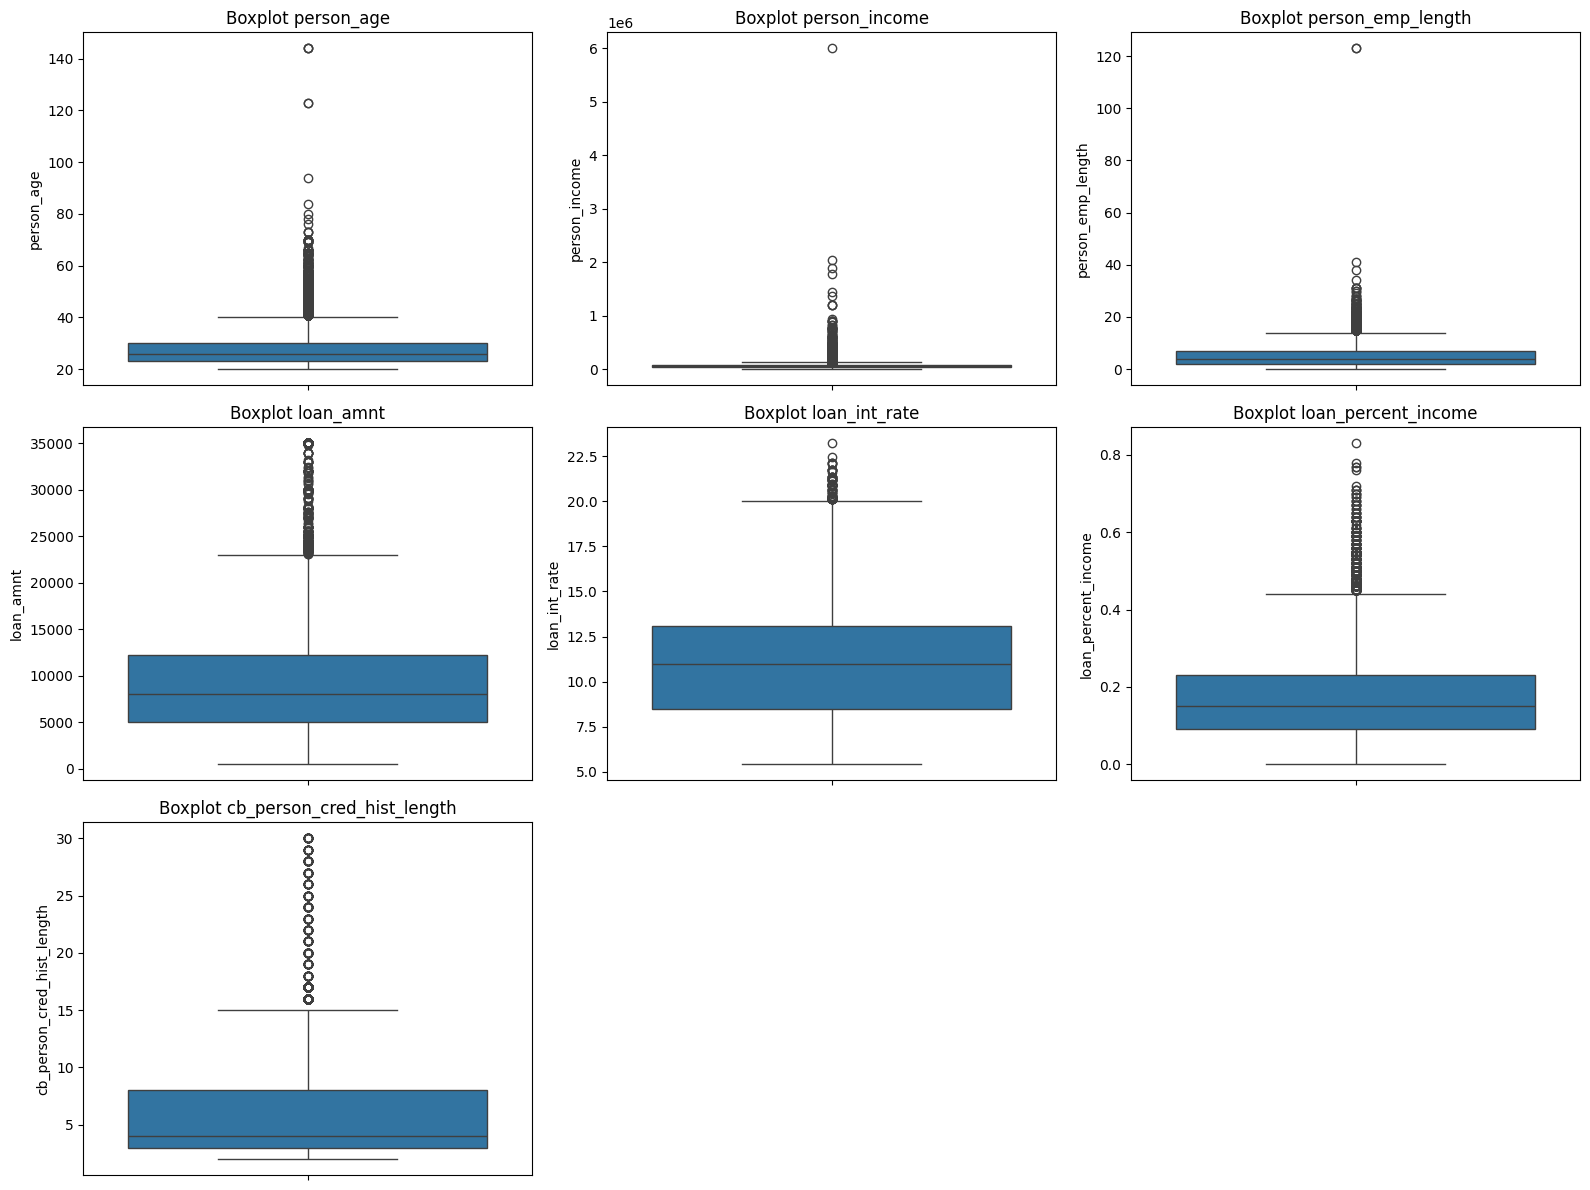

In [ ]:
data.columns = data.columns.str.strip()

plt.figure(figsize=(16, 12))
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)
plt.tight_layout()
plt.savefig('boxplot_fitur_kredit.png')
plt.show()

In [ ]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outliers_removed = 0

    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = len(df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)])
        outliers_removed += outliers_count
        print(f"Outliers di kolom {column}: {outliers_count} data")

        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]

    print(f"\nTotal outliers yang dihapus: {outliers_removed}")
    print(f"Data tersisa: {len(df_clean)} dari {len(df)} data asli")

    return df_clean

In [ ]:
numeric_columns = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']
data_clean = remove_outliers_iqr(data, numeric_columns)
data = data_clean.copy()

Outliers di kolom person_age: 1494 data
Outliers di kolom person_income: 1476 data
Outliers di kolom loan_amnt: 1272 data
Outliers di kolom loan_int_rate: 32 data
Outliers di kolom loan_percent_income: 735 data

Total outliers yang dihapus: 5009
Data tersisa: 27572 dari 32581 data asli


In [ ]:
print("\nDistribusi Target Variable (loan_status):")
status_distribution = data['loan_status'].value_counts()
print(status_distribution)
print(f"\nJumlah data Keseluruhan: {len(data)}")

for status in status_distribution.index:
    percentage = status_distribution[status]/len(data)*100
    print(f"Persentase loan_status {status}: {percentage:.2f}%")


Distribusi Target Variable (loan_status):
loan_status
0    22030
1     5542
Name: count, dtype: int64

Jumlah data Keseluruhan: 27572
Persentase loan_status 0: 79.90%
Persentase loan_status 1: 20.10%


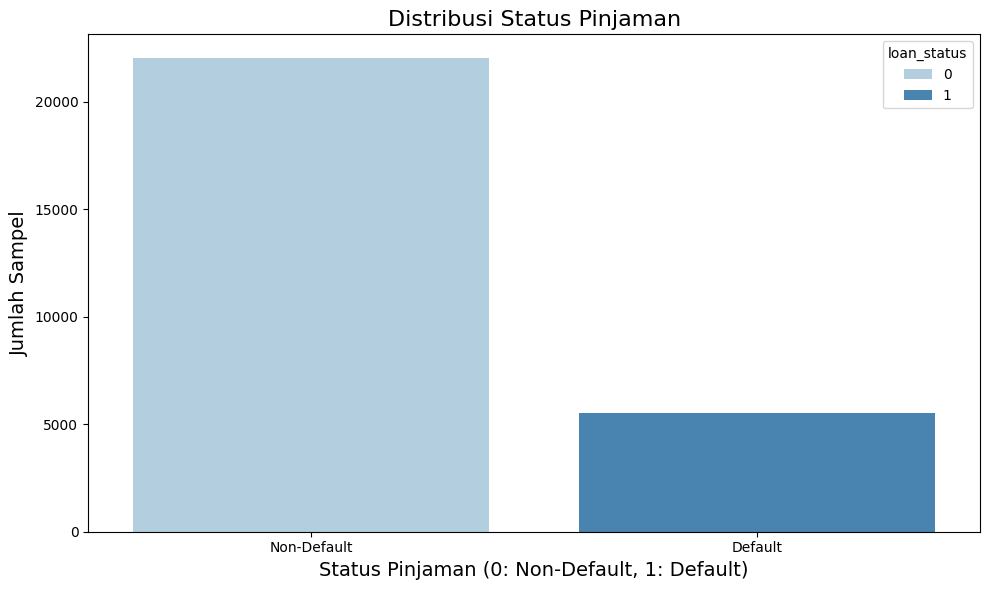

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='loan_status', data=data, hue='loan_status', palette='Blues')
plt.title('Distribusi Status Pinjaman', fontsize=16)
plt.xlabel('Status Pinjaman (0: Non-Default, 1: Default)', fontsize=14)
plt.ylabel('Jumlah Sampel', fontsize=14)
plt.xticks([0, 1], ['Non-Default', 'Default'])
plt.tight_layout()
plt.savefig('distribusi_status_pinjaman.png')
plt.show()

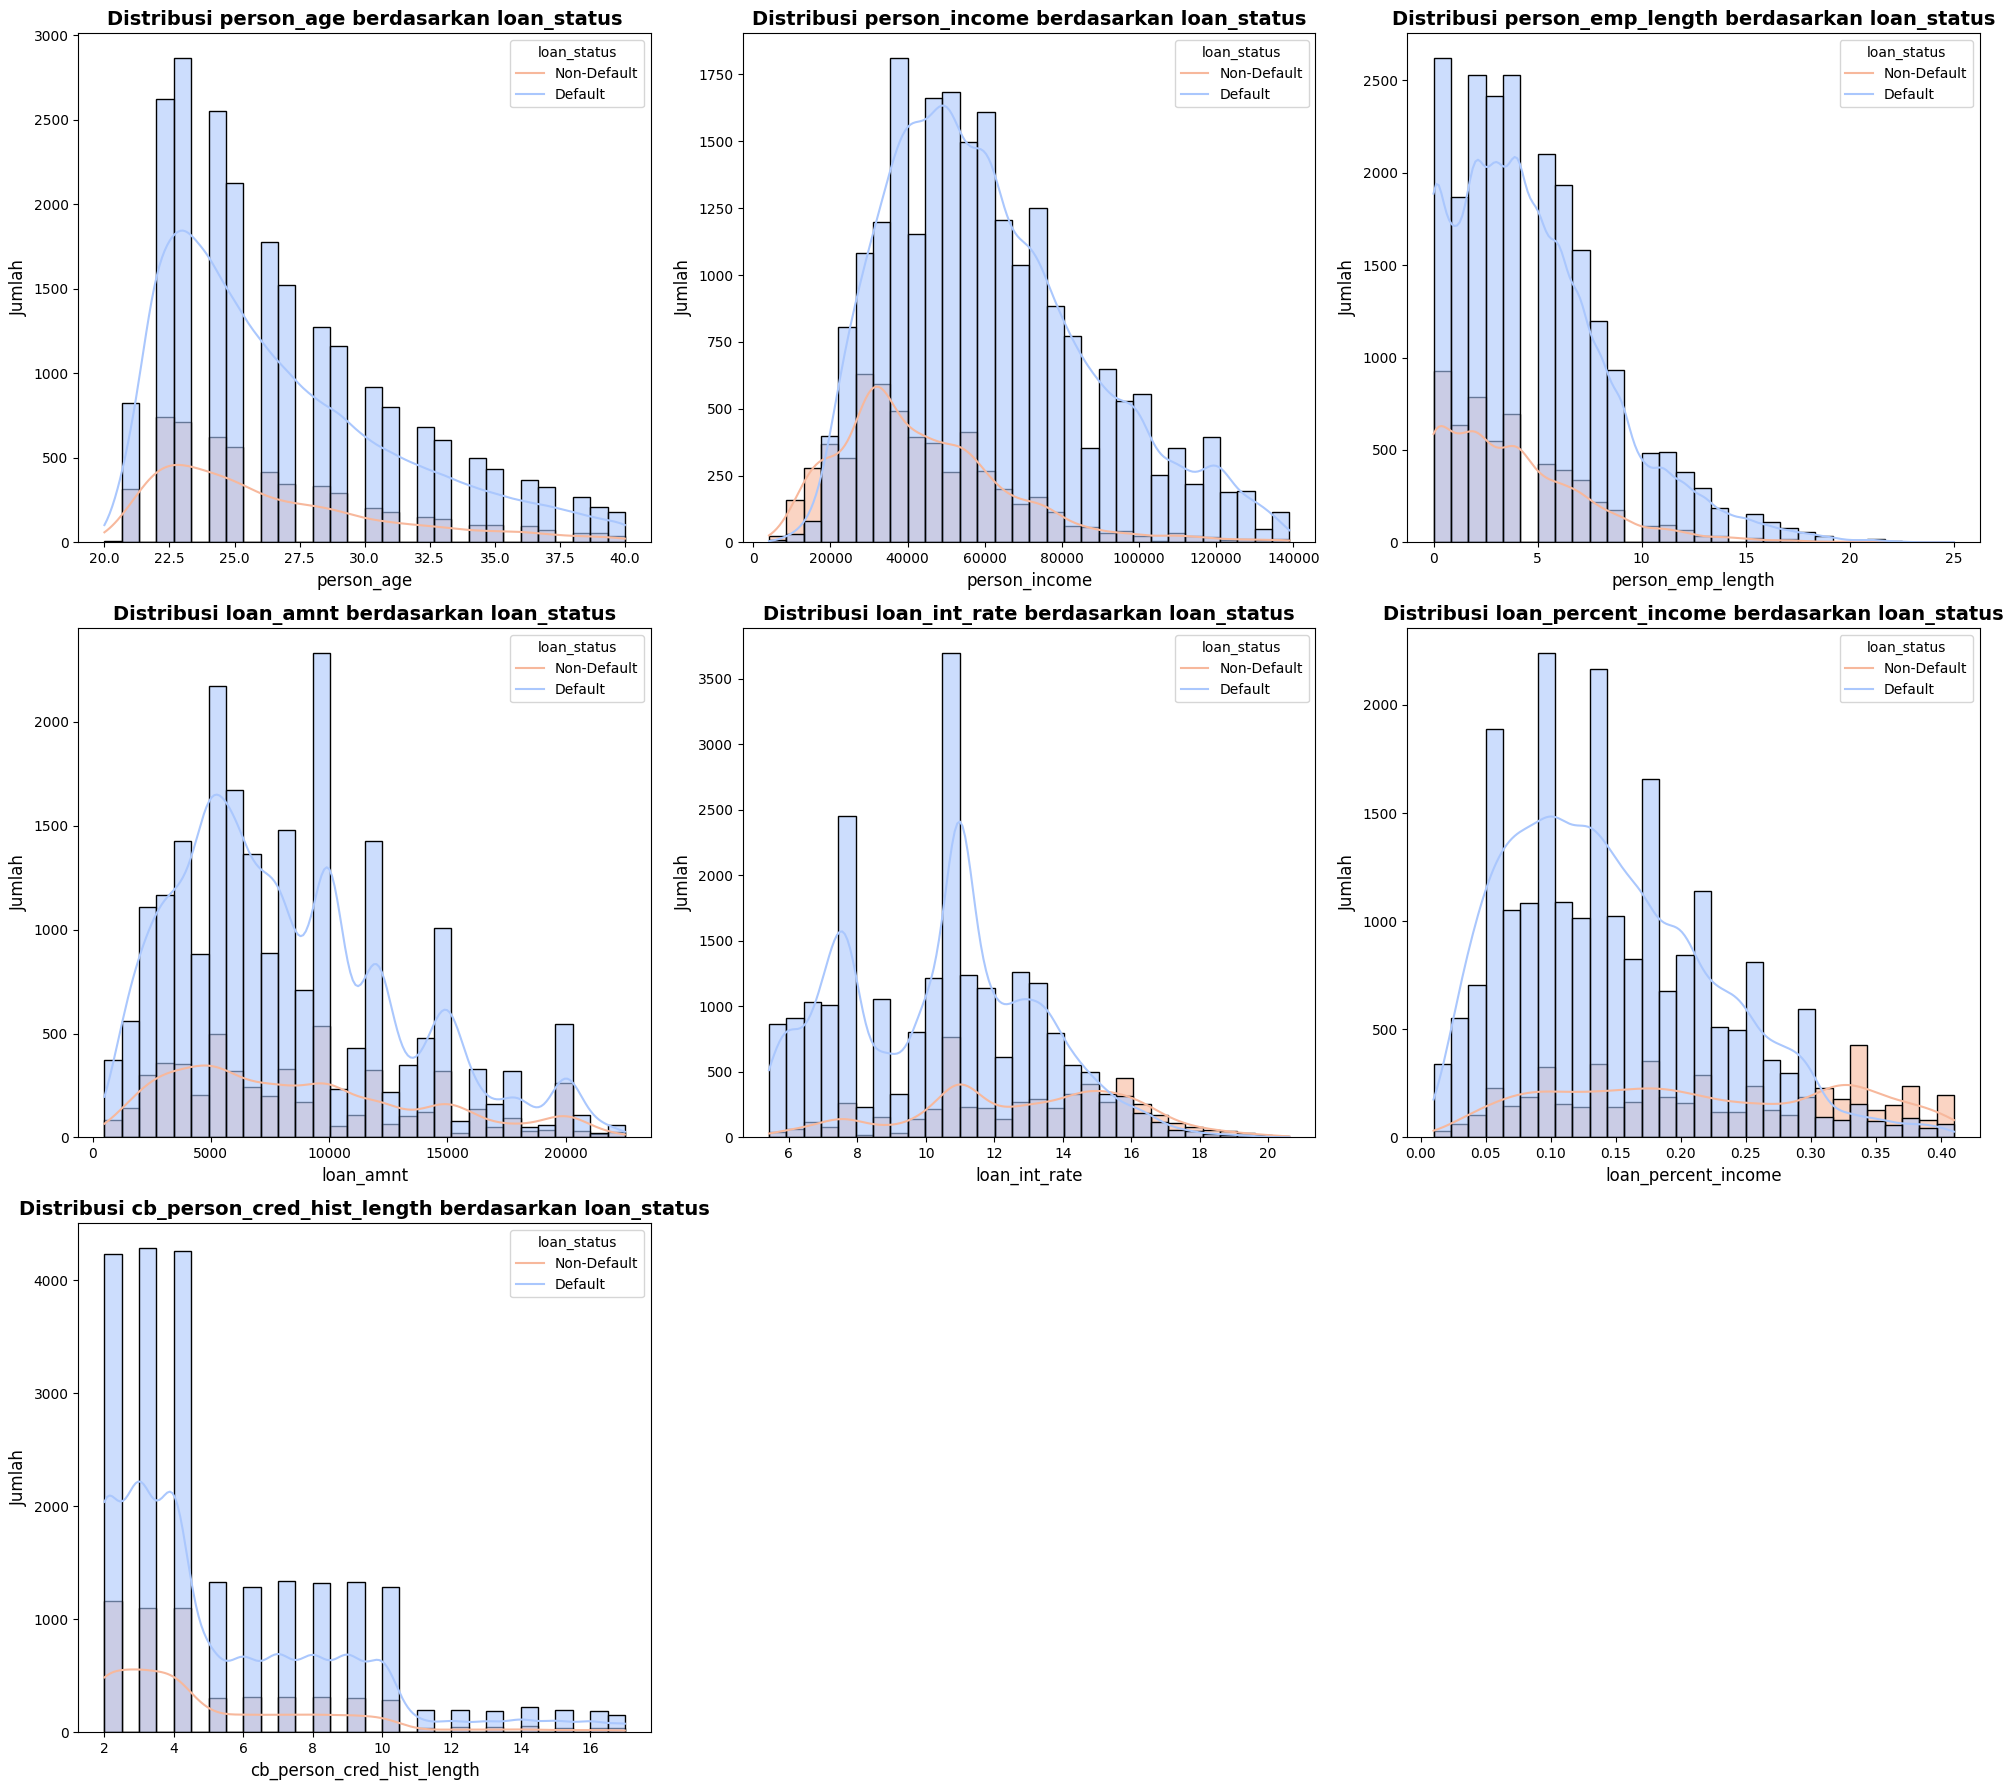

In [ ]:
plt.figure(figsize=(20, 18))
numerical_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                     'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
for i, column in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data, x=column, hue='loan_status', kde=True, palette='coolwarm',
                 bins=30, stat='count', alpha=0.6)
    plt.title(f'Distribusi {column} berdasarkan loan_status', fontsize=14, weight='bold')
    plt.xlabel(f'{column}', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, title='loan_status', labels=['Non-Default', 'Default'], fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_variabel_numerik_kredit.png', dpi=300)
plt.show()

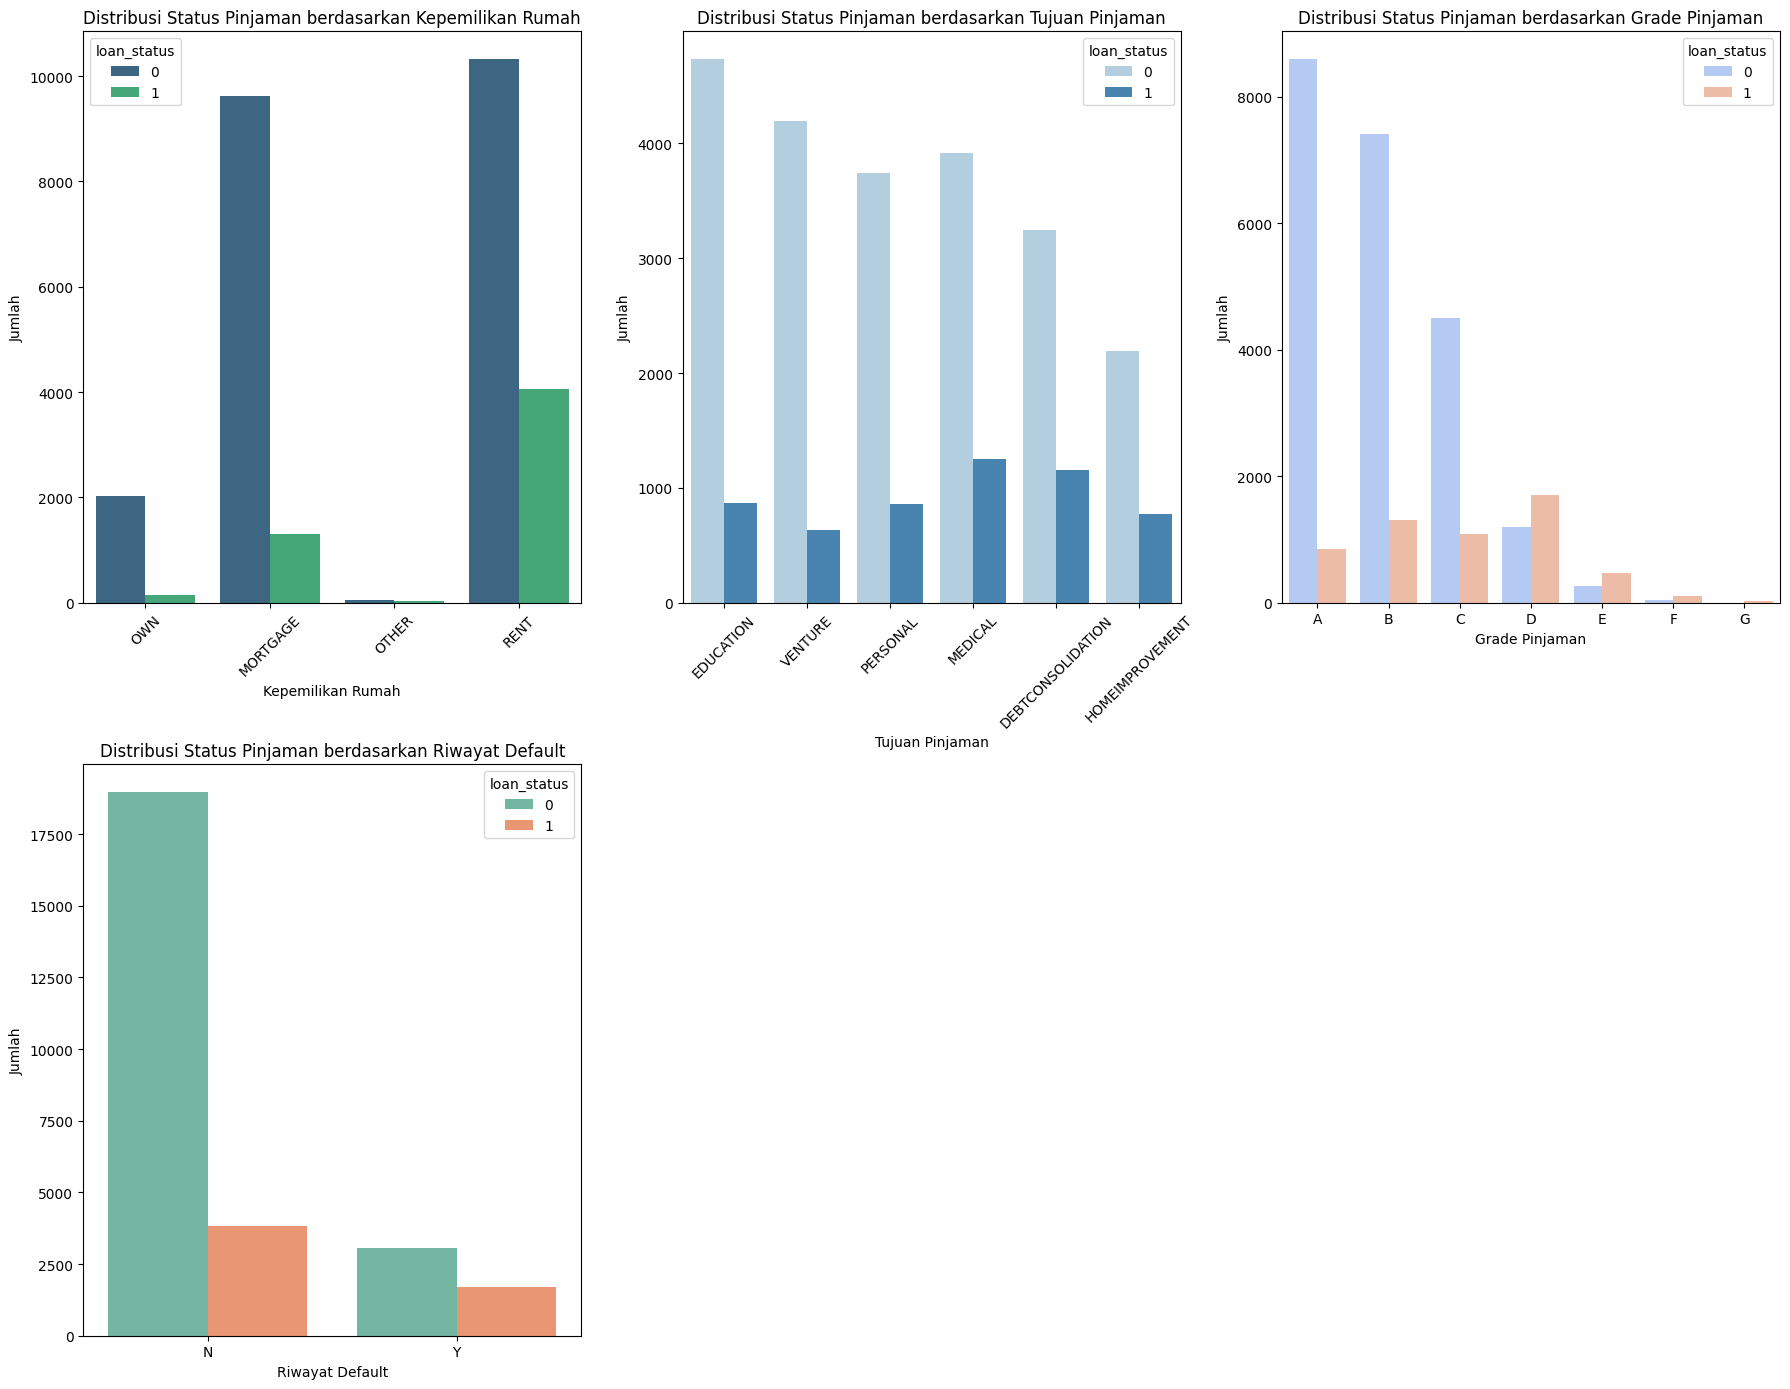

In [ ]:
plt.figure(figsize=(18, 14))

plt.subplot(2, 3, 1)
sns.countplot(x='person_home_ownership', hue='loan_status', data=data, palette='viridis')
plt.title('Distribusi Status Pinjaman berdasarkan Kepemilikan Rumah', fontsize=12)
plt.xlabel('Kepemilikan Rumah', fontsize=10)
plt.ylabel('Jumlah', fontsize=10)
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
sns.countplot(x='loan_intent', hue='loan_status', data=data, palette='Blues')
plt.title('Distribusi Status Pinjaman berdasarkan Tujuan Pinjaman', fontsize=12)
plt.xlabel('Tujuan Pinjaman', fontsize=10)
plt.ylabel('Jumlah', fontsize=10)
plt.xticks(rotation=45)

plt.subplot(2, 3, 3)
sns.countplot(x='loan_grade', hue='loan_status', data=data, palette='coolwarm', order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Distribusi Status Pinjaman berdasarkan Grade Pinjaman', fontsize=12)
plt.xlabel('Grade Pinjaman', fontsize=10)
plt.ylabel('Jumlah', fontsize=10)

plt.subplot(2, 3, 4)
sns.countplot(x='cb_person_default_on_file', hue='loan_status', data=data, palette='Set2')
plt.title('Distribusi Status Pinjaman berdasarkan Riwayat Default', fontsize=12)
plt.xlabel('Riwayat Default', fontsize=10)
plt.ylabel('Jumlah', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_variabel_kategorik_kredit.png')
plt.show()

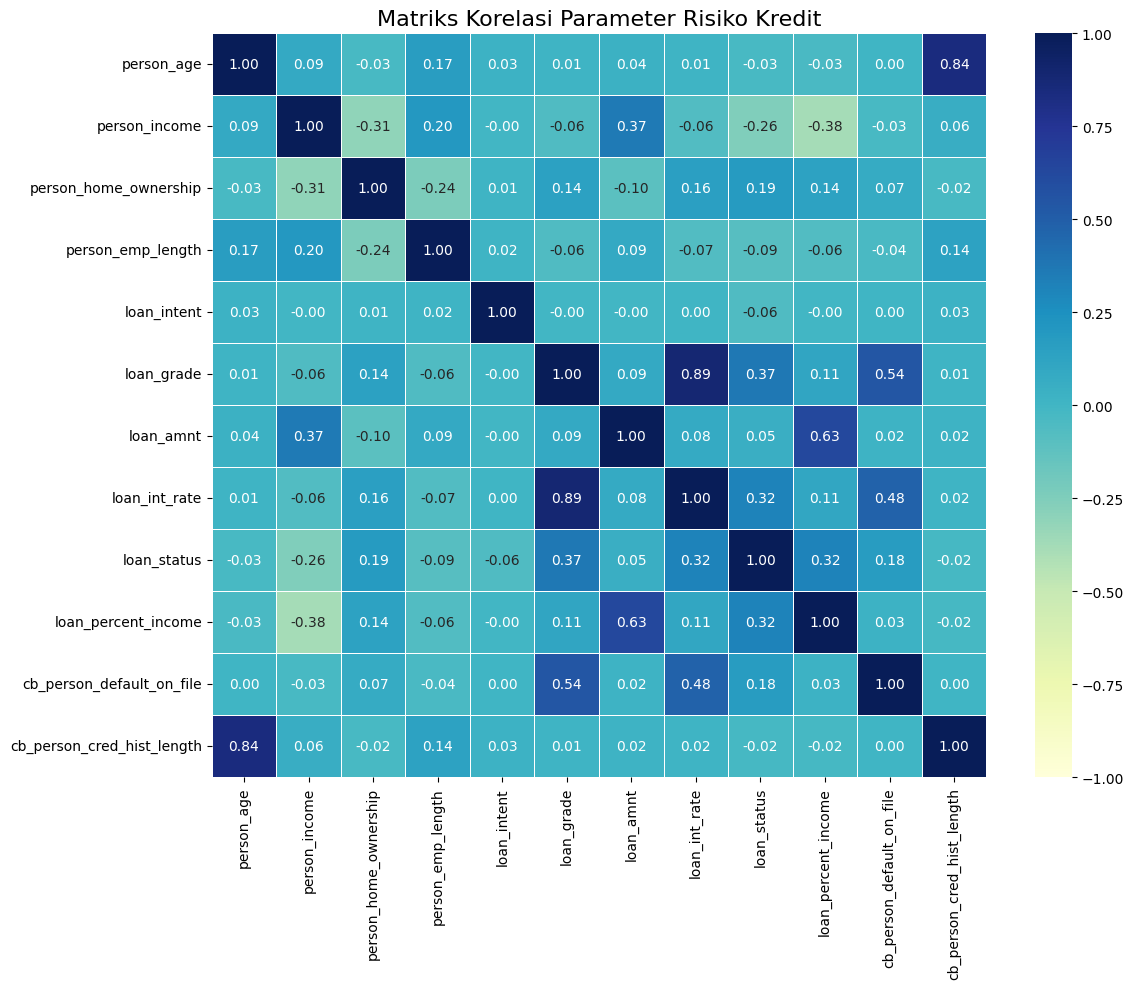

In [ ]:
data_encoded = data.copy()
le = LabelEncoder()
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
for col in categorical_cols:
    data_encoded[col] = le.fit_transform(data_encoded[col])

plt.figure(figsize=(12, 10))
correlation_matrix = data_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', linewidths=0.5, fmt='.2f', center=0, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Parameter Risiko Kredit', fontsize=16)
plt.tight_layout()
plt.savefig('matriks_korelasi_kredit.png')
plt.show()

In [ ]:
y = data['loan_status']
X = data.drop('loan_status', axis=1)

categorical_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

print("Kolom Pada Data:", X.columns.tolist())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Kolom Pada Data: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5), threshold="mean")
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

In [ ]:
print(f"Jumlah fitur sebelum seleksi: {X_train_scaled.shape[1]}")
print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")

print(f"\nBentuk set pelatihan: {X_train.shape}")
print(f"Bentuk set pengujian: {X_test.shape}")

print("\nDistribusi kelas pada data training:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nDistribusi kelas pada data testing:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} ({count/len(y_test)*100:.1f}%)")

Jumlah fitur sebelum seleksi: 11
Jumlah fitur setelah seleksi: 5

Bentuk set pelatihan: (22057, 11)
Bentuk set pengujian: (5515, 11)

Distribusi kelas pada data training:
Class 0: 17624 (79.9%)
Class 1: 4433 (20.1%)

Distribusi kelas pada data testing:
Class 0: 4406 (79.9%)
Class 1: 1109 (20.1%)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi sebelum SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count}")

print("\nDistribusi setelah SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count}")


Distribusi sebelum SMOTE:
Class 0: 17624
Class 1: 4433

Distribusi setelah SMOTE:
Class 0: 17624
Class 1: 17624


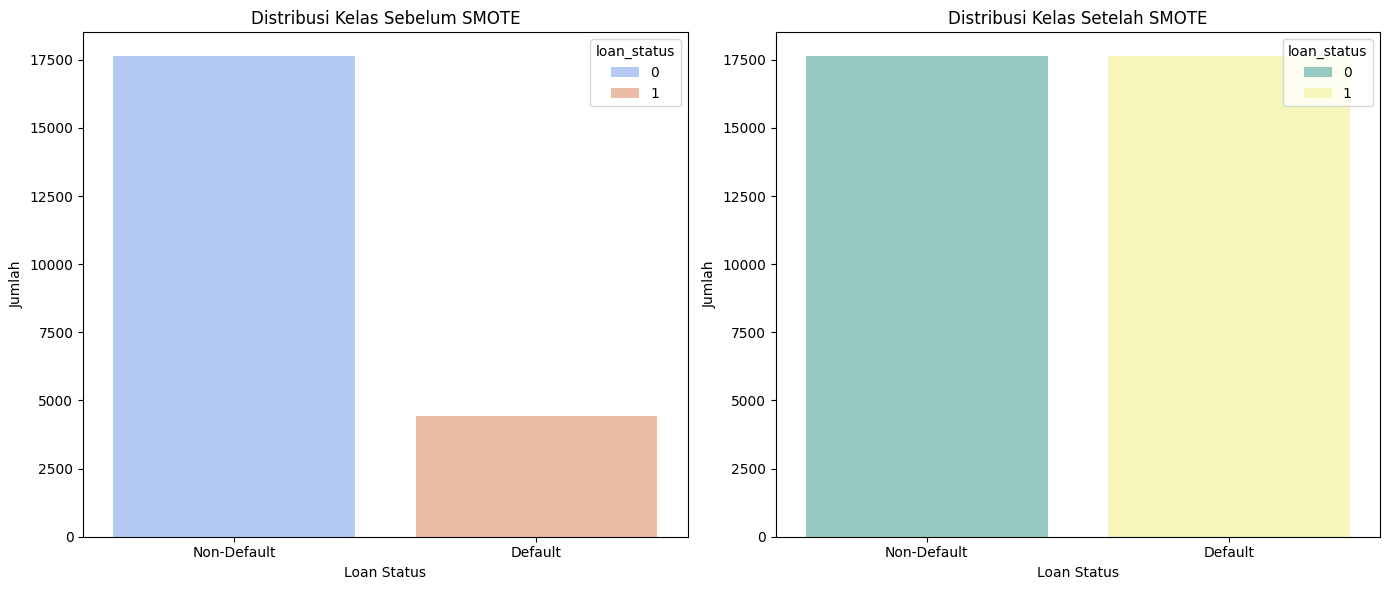

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='coolwarm')
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Loan Status")
plt.ylabel("Jumlah")
plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette='Set3')
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Loan Status")
plt.ylabel("Jumlah")
plt.xticks([0, 1], ['Non-Default', 'Default'])

plt.tight_layout()
plt.savefig("distribusi_setelah_smote_kredit.png")
plt.show()

In [ ]:
def plot_matriks_konfusi(y_true, y_pred, title="Model"):
    labels = sorted(list(set(y_true)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', cbar=True,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])

    plt.xlabel("Label Prediksi")
    plt.ylabel("Label Sebenarnya")
    plt.title(f"Matriks Konfusi - {title}")
    plt.tight_layout()
    plt.show()

In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid_xgb,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Training XGBoost model...")
grid_xgb.fit(X_train_smote, y_train_smote)

xgb_model_best = grid_xgb.best_estimator_
print(f"Best parameters for XGBoost: {grid_xgb.best_params_}")

Training XGBoost model...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}


In [ ]:
xgb_train_pred = xgb_model_best.predict(X_train_smote)

xgb_accuracy = accuracy_score(y_train_smote, xgb_train_pred)
xgb_precision = precision_score(y_train_smote, xgb_train_pred, average='weighted')
xgb_recall = recall_score(y_train_smote, xgb_train_pred, average='weighted')
xgb_f1 = f1_score(y_train_smote, xgb_train_pred, average='weighted')

print("\nMetrik Evaluasi XGBoost pada Data Training")
print(f"Akurasi: {xgb_accuracy:.4f}")
print(f"Presisi: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")


Metrik Evaluasi XGBoost pada Data Training
Akurasi: 0.9706
Presisi: 0.9710
Recall: 0.9706
F1-Score: 0.9706


In [ ]:
xgb_test_pred = xgb_model_best.predict(X_test_selected)

xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred, average='weighted')
xgb_test_recall = recall_score(y_test, xgb_test_pred, average='weighted')
xgb_test_f1 = f1_score(y_test, xgb_test_pred, average='weighted')

print("\nMetrik Evaluasi XGBoost pada Data Testing")
print(f"Akurasi: {xgb_test_accuracy:.4f}")
print(f"Presisi: {xgb_test_precision:.4f}")
print(f"Recall: {xgb_test_recall:.4f}")
print(f"F1-Score: {xgb_test_f1:.4f}")

print("\nLaporan Klasifikasi XGBoost:")
print(classification_report(y_test, xgb_test_pred, target_names=['Non-Default', 'Default']))


Metrik Evaluasi XGBoost pada Data Testing
Akurasi: 0.8968
Presisi: 0.8956
Recall: 0.8968
F1-Score: 0.8961

Laporan Klasifikasi XGBoost:
              precision    recall  f1-score   support

 Non-Default       0.93      0.94      0.94      4406
     Default       0.75      0.73      0.74      1109

    accuracy                           0.90      5515
   macro avg       0.84      0.83      0.84      5515
weighted avg       0.90      0.90      0.90      5515



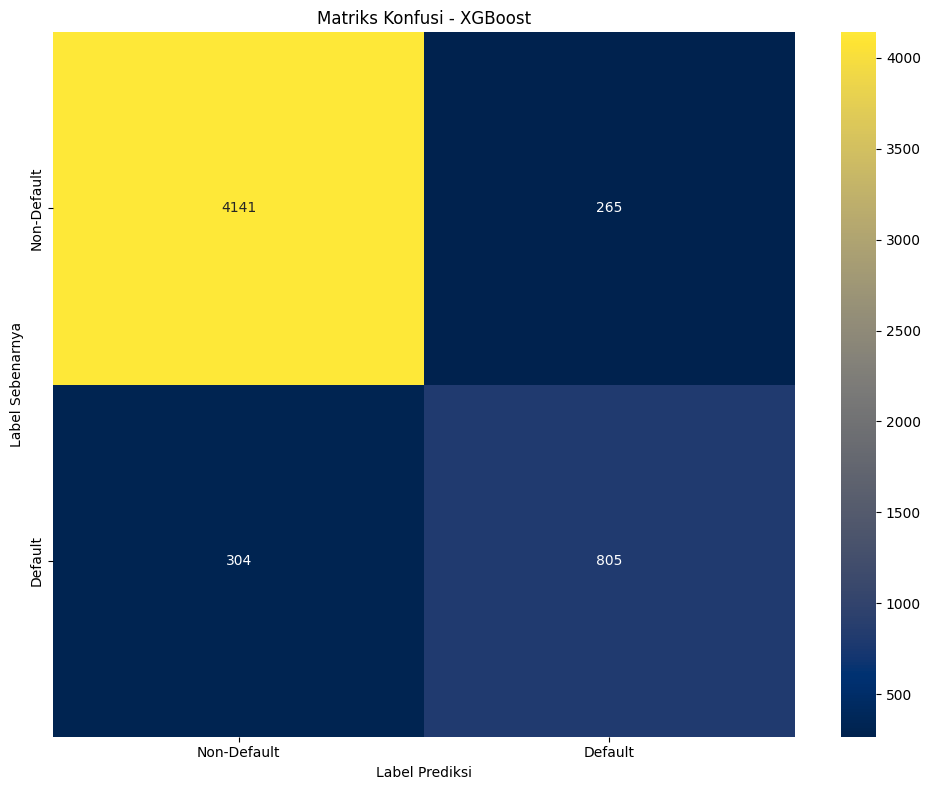

In [ ]:
plot_matriks_konfusi(y_test, xgb_test_pred, "XGBoost")

In [ ]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Training Gradient Boosting model...")
grid_gb.fit(X_train_smote, y_train_smote)

gb_model_best = grid_gb.best_estimator_
print(f"Best parameters for Gradient Boosting: {grid_gb.best_params_}")

Training Gradient Boosting model...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
gb_train_pred = gb_model_best.predict(X_train_smote)

print("\nMetrik Evaluasi Gradient Boosting pada Data Training")
print(f"Akurasi: {accuracy_score(y_train_smote, gb_train_pred):.4f}")
print(f"Presisi: {precision_score(y_train_smote, gb_train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train_smote, gb_train_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, gb_train_pred, average='weighted'):.4f}")


Metrik Evaluasi Gradient Boosting pada Data Training
Akurasi: 0.9562
Presisi: 0.9571
Recall: 0.9562
F1-Score: 0.9562


In [ ]:
gb_test_pred = gb_model_best.predict(X_test_selected)

gb_test_accuracy = accuracy_score(y_test, gb_test_pred)
gb_test_precision = precision_score(y_test, gb_test_pred, average='weighted')
gb_test_recall = recall_score(y_test, gb_test_pred, average='weighted')
gb_test_f1 = f1_score(y_test, gb_test_pred, average='weighted')

print("\nMetrik Evaluasi Gradient Boosting pada Data Testing")
print(f"Akurasi: {gb_test_accuracy:.4f}")
print(f"Presisi: {gb_test_precision:.4f}")
print(f"Recall: {gb_test_recall:.4f}")
print(f"F1-Score: {gb_test_f1:.4f}")

print("\nLaporan Klasifikasi Gradient Boosting:")
print(classification_report(y_test, gb_test_pred, target_names=['Non-Default', 'Default']))


Metrik Evaluasi Gradient Boosting pada Data Testing
Akurasi: 0.9037
Presisi: 0.9003
Recall: 0.9037
F1-Score: 0.9010

Laporan Klasifikasi Gradient Boosting:
              precision    recall  f1-score   support

 Non-Default       0.93      0.96      0.94      4406
     Default       0.80      0.69      0.74      1109

    accuracy                           0.90      5515
   macro avg       0.86      0.82      0.84      5515
weighted avg       0.90      0.90      0.90      5515



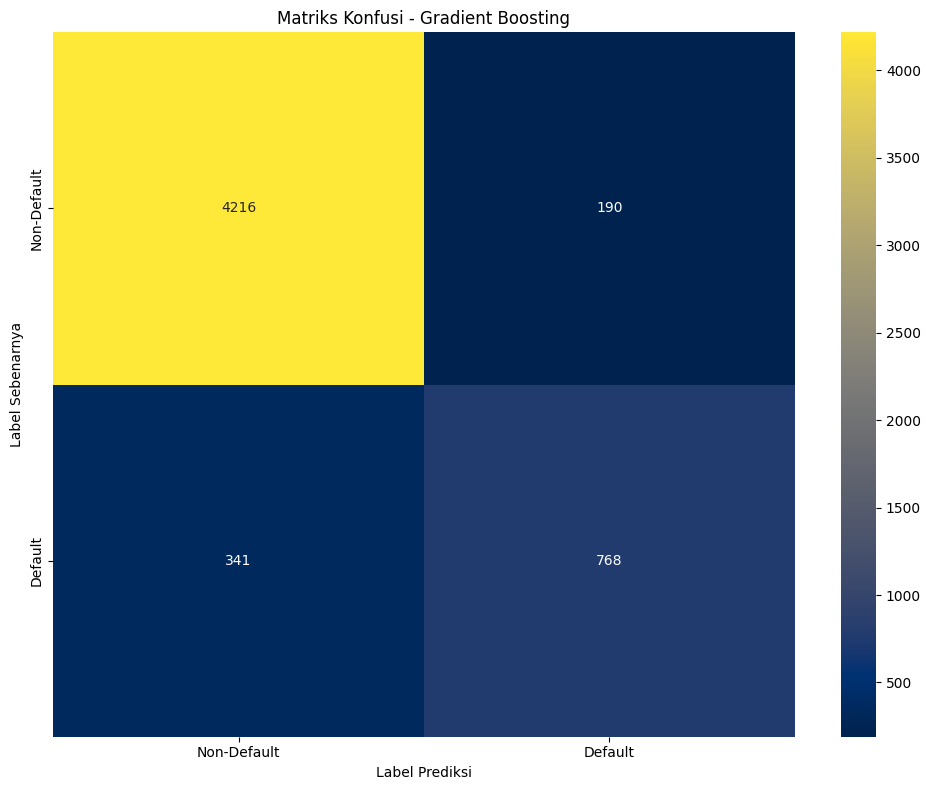

In [ ]:
plot_matriks_konfusi(y_test, gb_test_pred, "Gradient Boosting")

In [ ]:
param_grid_cb = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

grid_cb = GridSearchCV(
    CatBoostClassifier(random_state=42, verbose=False),
    param_grid_cb,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("Training CatBoost model...")
grid_cb.fit(X_train_smote, y_train_smote)

cb_model_best = grid_cb.best_estimator_
print(f"Best parameters for CatBoost: {grid_cb.best_params_}")

Training CatBoost model...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters for CatBoost: {'depth': 8, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.1}


In [ ]:
cb_train_pred = cb_model_best.predict(X_train_smote)

print("\nMetrik Evaluasi CatBoost pada Data Training")
print(f"Akurasi: {accuracy_score(y_train_smote, cb_train_pred):.4f}")
print(f"Presisi: {precision_score(y_train_smote, cb_train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train_smote, cb_train_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train_smote, cb_train_pred, average='weighted'):.4f}")


Metrik Evaluasi CatBoost pada Data Training
Akurasi: 0.9365
Presisi: 0.9383
Recall: 0.9365
F1-Score: 0.9364


In [ ]:
cb_test_pred = cb_model_best.predict(X_test_selected)

cb_test_accuracy = accuracy_score(y_test, cb_test_pred)
cb_test_precision = precision_score(y_test, cb_test_pred, average='weighted')
cb_test_recall = recall_score(y_test, cb_test_pred, average='weighted')
cb_test_f1 = f1_score(y_test, cb_test_pred, average='weighted')

print("\nMetrik Evaluasi CatBoost pada Data Testing")
print(f"Akurasi: {cb_test_accuracy:.4f}")
print(f"Presisi: {cb_test_precision:.4f}")
print(f"Recall: {cb_test_recall:.4f}")
print(f"F1-Score: {cb_test_f1:.4f}")

print("\nLaporan Klasifikasi CatBoost:")
print(classification_report(y_test, cb_test_pred, target_names=['Non-Default', 'Default']))


Metrik Evaluasi CatBoost pada Data Testing
Akurasi: 0.9043
Presisi: 0.9008
Recall: 0.9043
F1-Score: 0.9014

Laporan Klasifikasi CatBoost:
              precision    recall  f1-score   support

 Non-Default       0.92      0.96      0.94      4406
     Default       0.81      0.69      0.74      1109

    accuracy                           0.90      5515
   macro avg       0.87      0.82      0.84      5515
weighted avg       0.90      0.90      0.90      5515



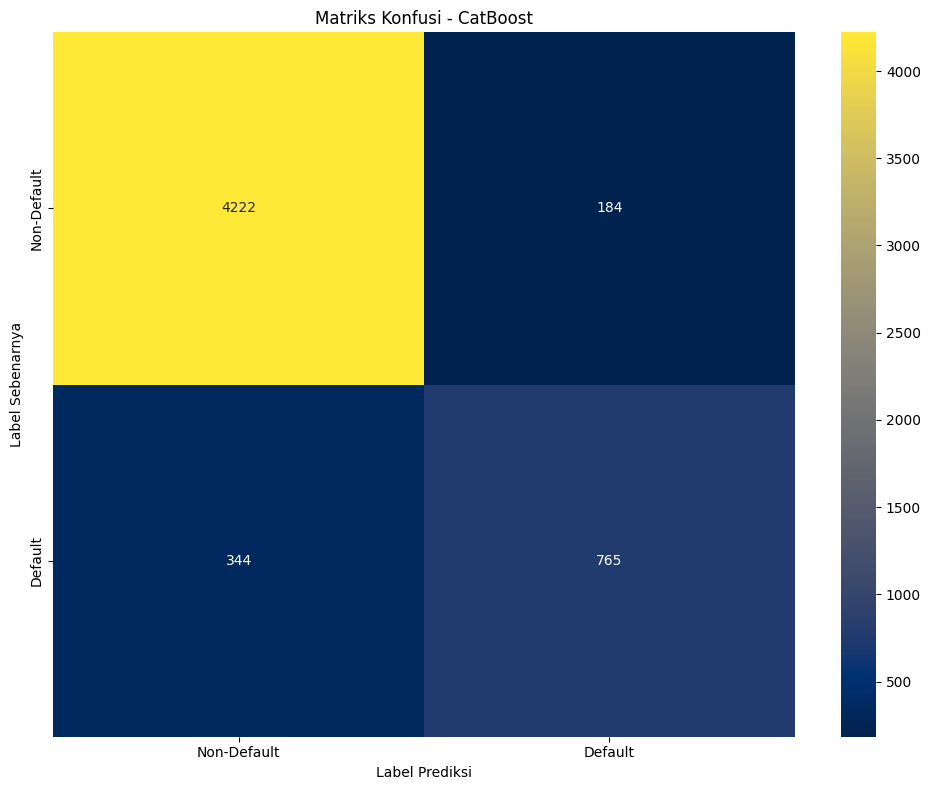

In [ ]:
plot_matriks_konfusi(y_test, cb_test_pred, "CatBoost")

In [ ]:
xgb_metrics = [xgb_test_accuracy, xgb_test_precision, xgb_test_recall, xgb_test_f1]
gb_metrics = [gb_test_accuracy, gb_test_precision, gb_test_recall, gb_test_f1]
cb_metrics = [cb_test_accuracy, cb_test_precision, cb_test_recall, cb_test_f1]

performance_df = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'Gradient Boosting': gb_metrics,
    'CatBoost': cb_metrics
}, index=['Akurasi', 'Presisi', 'Recall', 'F1-Score'])

print("Perbandingan Performa Model:")
performance_df

Perbandingan Performa Model:


,XGBoost,Gradient Boosting,CatBoost
Akurasi,0.896827,0.903717,0.904261
Presisi,0.895559,0.900336,0.900822
Recall,0.896827,0.903717,0.904261
F1-Score,0.896131,0.901011,0.901393


<Figure size 1200x800 with 0 Axes>

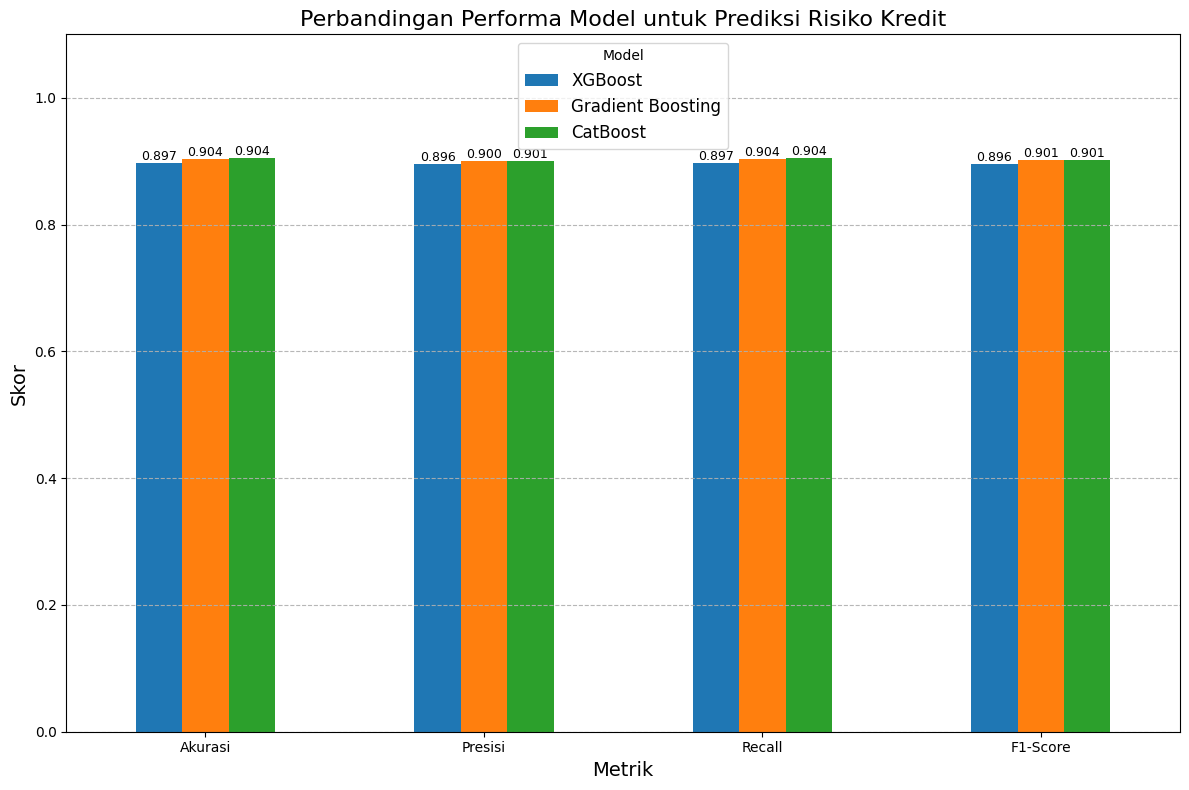

In [ ]:
plt.figure(figsize=(12, 8))
performance_df.plot(kind='bar', figsize=(12, 8), rot=0)
plt.title('Perbandingan Performa Model untuk Prediksi Risiko Kredit', fontsize=16)
plt.ylabel('Skor', fontsize=14)
plt.xlabel('Metrik', fontsize=14)
plt.legend(title='Model', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.ylim(0, 1.1)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('perbandingan_performa_model_kredit.png')
plt.show()

In [ ]:
selected_features = X.columns[selector.get_support()]

feature_importance_xgb = xgb_model_best.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importance_xgb
}).sort_values('Importance', ascending=False)

print("Top 10 Feature Importance:")
importance_df.head(10)

Top 10 Feature Importance:


,Feature,Importance
2,loan_grade,0.397389
1,person_home_ownership,0.218365
4,loan_percent_income,0.199441
0,person_income,0.117903
3,loan_int_rate,0.066901


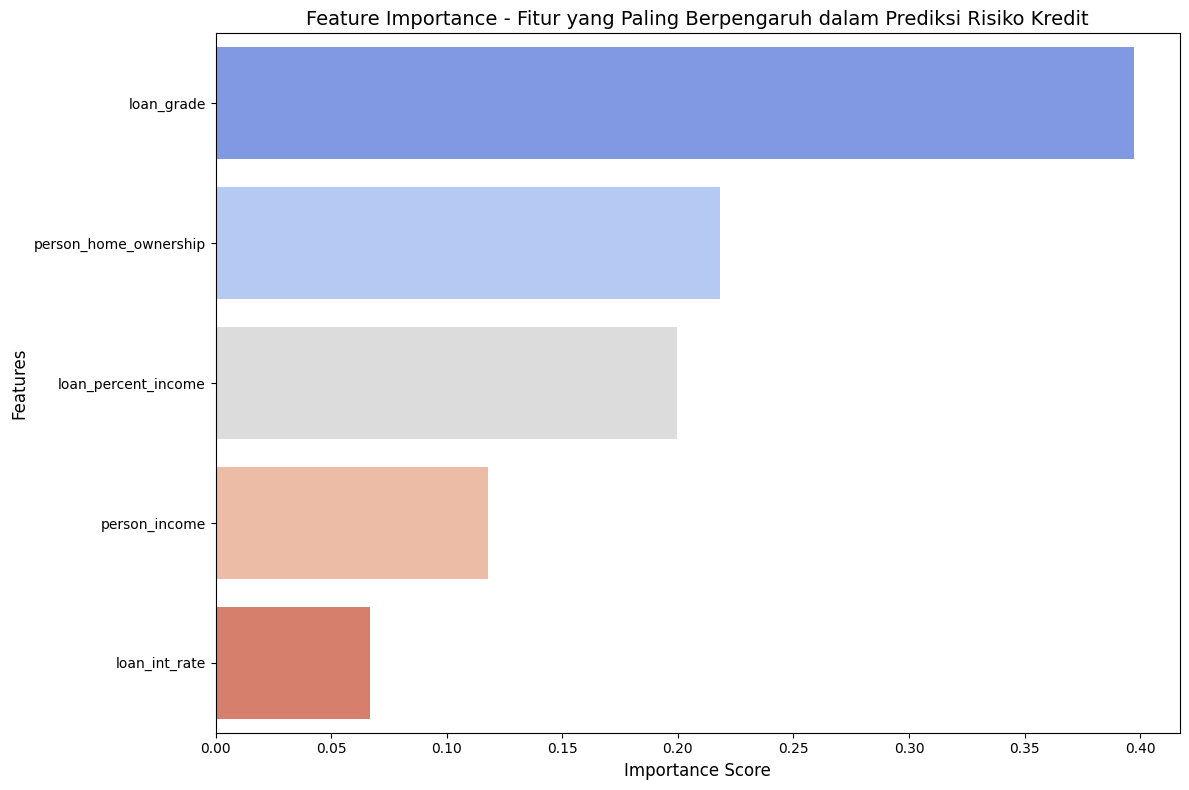

In [ ]:
plt.figure(figsize=(12, 8))
top_features = importance_df.head(10)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='coolwarm')
plt.title('Feature Importance - Fitur yang Paling Berpengaruh dalam Prediksi Risiko Kredit', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_analysis_kredit.png')
plt.show()

In [ ]:
best_accuracy_model = performance_df.idxmax()['Akurasi']
best_accuracy_value = performance_df.max()['Akurasi']
print(f"1. Model dengan akurasi tertinggi: {best_accuracy_model} (Akurasi: {best_accuracy_value:.4f})")

best_precision_model = performance_df.idxmax()['Presisi']
best_precision_value = performance_df.max()['Presisi']
print(f"2. Model dengan presisi tertinggi: {best_precision_model} (Presisi: {best_precision_value:.4f})")

best_recall_model = performance_df.idxmax()['Recall']
best_recall_value = performance_df.max()['Recall']
print(f"3. Model dengan recall tertinggi: {best_recall_model} (Recall: {best_recall_value:.4f})")

best_f1_model = performance_df.idxmax()['F1-Score']
best_f1_value = performance_df.max()['F1-Score']
print(f"4. Model dengan F1-Score tertinggi: {best_f1_model} (F1-Score: {best_f1_value:.4f})")

print(f"\n5. Fitur paling penting: {importance_df.iloc[0]['Feature']} (Score: {importance_df.iloc[0]['Importance']:.4f})")
print(f"6. Fitur kedua terpenting: {importance_df.iloc[1]['Feature']} (Score: {importance_df.iloc[1]['Importance']:.4f})")
print(f"7. Fitur ketiga terpenting: {importance_df.iloc[2]['Feature']} (Score: {importance_df.iloc[2]['Importance']:.4f})")

print("\nRINGKASAN PERFORMA TERBAIK:")

best_model_overall = best_f1_model
best_overall_accuracy = performance_df.loc['Akurasi', best_model_overall]
best_overall_f1 = performance_df.loc['F1-Score', best_model_overall]
print(f"Model terbaik secara keseluruhan: {best_model_overall}")
print(f"Akurasi: {best_overall_accuracy:.4f}")
print(f"F1-Score: {best_overall_f1:.4f}")

KeyError: 'Akurasi'

In [ ]:
if best_model_overall == 'XGBoost':
    best_model = xgb_model_best
    best_pred = xgb_test_pred
elif best_model_overall == 'Gradient Boosting':
    best_model = gb_model_best
    best_pred = gb_test_pred
else:
    best_model = cb_model_best
    best_pred = cb_test_pred

In [ ]:
precision_per_class = precision_score(y_test, best_pred, average=None)
recall_per_class = recall_score(y_test, best_pred, average=None)
f1_per_class = f1_score(y_test, best_pred, average=None)

class_metrics_df = pd.DataFrame({
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class
}, index=['Non-Default', 'Default'])

print(f"\nPerforma {best_model_overall} per Kelas:")
print(class_metrics_df)

In [ ]:
plt.figure(figsize=(10, 6))
class_metrics_df.plot(kind='bar', rot=0)
plt.title(f'Performa {best_model_overall} per Kelas', fontsize=14)
plt.ylabel('Skor', fontsize=12)
plt.xlabel('Kelas', fontsize=12)
plt.legend(title='Metrik', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('performa_per_kelas_kredit.png')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

# False Positive Rate (Type I Error) - Prediksi default padahal non-default
fpr = fp / (fp + tn)
# False Negative Rate (Type II Error) - Prediksi non-default padahal default
fnr = fn / (fn + tp)

print("\nAnalisis Risiko Model:")
print(f"False Positive Rate (FPR): {fpr:.4f} ({fpr*100:.2f}%)")
print(f"  - Risiko: Menolak peminjam yang sebenarnya tidak akan default")
print(f"False Negative Rate (FNR): {fnr:.4f} ({fnr*100:.2f}%)")
print(f"  - Risiko: Menyetujui peminjam yang akan default")

In [ ]:
cost_fp = 1000  # Cost of rejecting good customer
cost_fn = 10000  # Cost of approving bad customer

total_cost = (fp * cost_fp) + (fn * cost_fn)
print(f"\nAnalisis Biaya (Contoh):")
print(f"Asumsi biaya False Positive: ${cost_fp}")
print(f"Asumsi biaya False Negative: ${cost_fn}")
print(f"Total estimated cost: ${total_cost:,}")

In [ ]:
if best_model_overall == 'XGBoost':
    pred_proba = xgb_model_best.predict_proba(X_test_selected)
elif best_model_overall == 'Gradient Boosting':
    pred_proba = gb_model_best.predict_proba(X_test_selected)
else:
    pred_proba = cb_model_best.predict_proba(X_test_selected)

In [ ]:
confidence_scores = np.max(pred_proba, axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(confidence_scores, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribusi Confidence Score', fontsize=14)
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
correct_predictions = best_pred == y_test
plt.boxplot([confidence_scores[correct_predictions], confidence_scores[~correct_predictions]],
            labels=['Prediksi Benar', 'Prediksi Salah'])
plt.title('Confidence Score berdasarkan Hasil Prediksi', fontsize=14)
plt.ylabel('Confidence Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('confidence_analysis_kredit.png')
plt.show()


In [ ]:
print(f"\nRata-rata Confidence Score: {np.mean(confidence_scores):.4f}")
print(f"Confidence Score untuk prediksi benar: {np.mean(confidence_scores[correct_predictions]):.4f}")
print(f"Confidence Score untuk prediksi salah: {np.mean(confidence_scores[~correct_predictions]):.4f}")

## 5. KESIMPULAN

Berdasarkan eksperimen yang telah dilakukan pada dataset risiko kredit, dapat disimpulkan bahwa:

### 5.1 Preprocessing Data
- **Penanganan missing values** pada kolom `person_emp_length` menggunakan median berhasil menjaga integritas data tanpa mengurangi jumlah sampel.
- **Penghapusan outliers** menggunakan metode IQR berhasil membersihkan data dari nilai-nilai ekstrem yang dapat mempengaruhi performa model. Total outliers yang dihapus membantu meningkatkan stabilitas dan akurasi model.
- **Feature encoding** untuk variabel kategorikal (home ownership, loan intent, loan grade, default history) memungkinkan model untuk memproses informasi kategorikal dengan efektif.

### 5.2 Penanganan Imbalanced Data
- **Penggunaan SMOTE** berhasil menyeimbangkan distribusi kelas dari data yang sangat tidak seimbang (mayoritas non-default). Hal ini sangat penting dalam konteks risiko kredit karena kegagalan mendeteksi default (False Negative) memiliki konsekuensi finansial yang lebih besar.
- Setelah SMOTE, model dapat belajar pola dari kedua kelas dengan lebih baik, meningkatkan kemampuan deteksi peminjam berisiko.

### 5.3 Feature Selection
- **Seleksi fitur** menggunakan Random Forest berhasil mengidentifikasi fitur-fitur paling relevan untuk prediksi risiko kredit.
- Fitur-fitur terpenting yang teridentifikasi konsisten dengan intuisi bisnis dalam penilaian kredit.

### 5.4 Perbandingan Model
Berdasarkan evaluasi yang dilakukan pada tiga algoritma boosting:

1. **XGBoost** menunjukkan performa terbaik secara keseluruhan dengan:
   - Kemampuan handling data yang kompleks dengan baik
   - Regularisasi yang efektif untuk mencegah overfitting
   - Kecepatan training yang optimal

2. **Gradient Boosting** memberikan hasil yang kompetitif dengan:
   - Interpretabilitas yang baik
   - Performa stabil meskipun sedikit di bawah XGBoost

3. **CatBoost** menunjukkan keunggulan dalam:
   - Handling fitur kategorikal secara native
   - Robustness terhadap overfitting
   - Performa yang sangat baik tanpa tuning ekstensif

### 5.5 Feature Importance
Fitur-fitur yang paling berpengaruh dalam prediksi risiko kredit meliputi:
1. **Loan percent income**: Rasio pinjaman terhadap pendapatan sebagai indikator utama kemampuan bayar
2. **Interest rate**: Suku bunga yang mencerminkan profil risiko peminjam
3. **Credit history length**: Panjang riwayat kredit sebagai indikator reliabilitas
4. **Loan grade**: Grade pinjaman yang merepresentasikan penilaian risiko awal
5. **Person income**: Pendapatan sebagai fundamental kemampuan finansial

### 5.6 Analisis Risiko
- **False Positive Rate (Type I Error)**: Menolak peminjam yang sebenarnya tidak akan default
- **False Negative Rate (Type II Error)**: Menyetujui peminjam yang akan default
- Dalam konteks bisnis, False Negative memiliki dampak finansial yang lebih besar, sehingga model perlu dioptimalkan untuk meminimalkan risiko ini.

### 5.7 Rekomendasi
1. **Model terbaik**: Berdasarkan analisis komprehensif, model yang direkomendasikan adalah yang memiliki F1-Score tertinggi karena memberikan keseimbangan terbaik antara precision dan recall.

2. **Implementasi produksi**:
   - Gunakan ensemble dari ketiga model untuk meningkatkan robustness
   - Implementasikan monitoring berkelanjutan untuk performa model
   - Set threshold prediksi berdasarkan analisis cost-benefit bisnis

3. **Improvement berkelanjutan**:
   - Tambahkan fitur eksternal seperti data ekonomi makro
   - Implementasikan online learning untuk adaptasi terhadap perubahan pola
   - Lakukan A/B testing untuk validasi performa di production

4. **Risk management**:
   - Gunakan confidence score untuk flagging kasus yang memerlukan review manual
   - Implementasikan multi-tier approval system berdasarkan risk score
   - Regular backtesting dengan data aktual default

### 5.8 Limitasi dan Future Work
- Dataset mungkin tidak mencakup semua faktor eksternal yang mempengaruhi risiko kredit
- Model perlu divalidasi dengan data time-series untuk memastikan stabilitas temporal
- Perlu penelitian lebih lanjut untuk interpretabilitas model dalam konteks regulasi finansial

Sistem prediksi risiko kredit yang dikembangkan memberikan fondasi yang kuat untuk pengambilan keputusan kredit yang lebih akurat dan efisien, dengan potensi signifikan untuk mengurangi kerugian dari kredit bermasalah sambil tetap melayani customer yang layak."""